In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported!")

✅ All libraries imported!


In [2]:
# Load dataset
df = pd.read_csv("data/breast-cancer.csv")
print("Dataset loaded!")
print("Shape:", df.shape)
df.head()

Dataset loaded!
Shape: (569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
# Check data types and nulls
print(df.info())
print("\n")
print("Null values:\n", df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

diagnosis
B    357
M    212
Name: count, dtype: int64


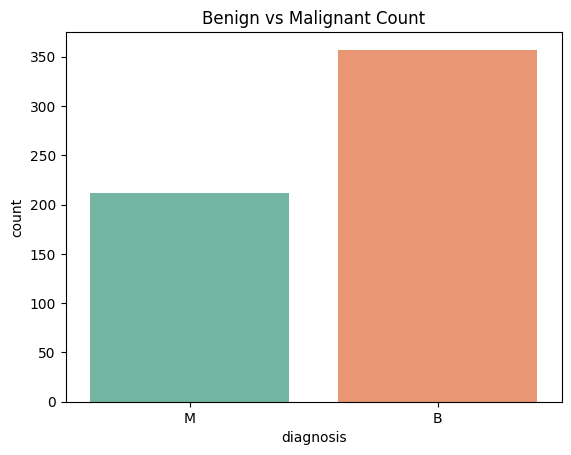

In [4]:
# How many Malignant vs Benign?
print(df['diagnosis'].value_counts())

# Plot it
sns.countplot(x='diagnosis', data=df, palette='Set2')
plt.title('Benign vs Malignant Count')
plt.show()

In [6]:
# Drop unnecessary columns (safely)
cols_to_drop = [col for col in ['id', 'Unnamed: 32'] if col in df.columns]
df = df.drop(cols_to_drop, axis=1)

# Encode target: M = 1, B = 0
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

print("✅ Data cleaned!")
print("Shape now:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

✅ Data cleaned!
Shape now: (569, 31)
Columns: ['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


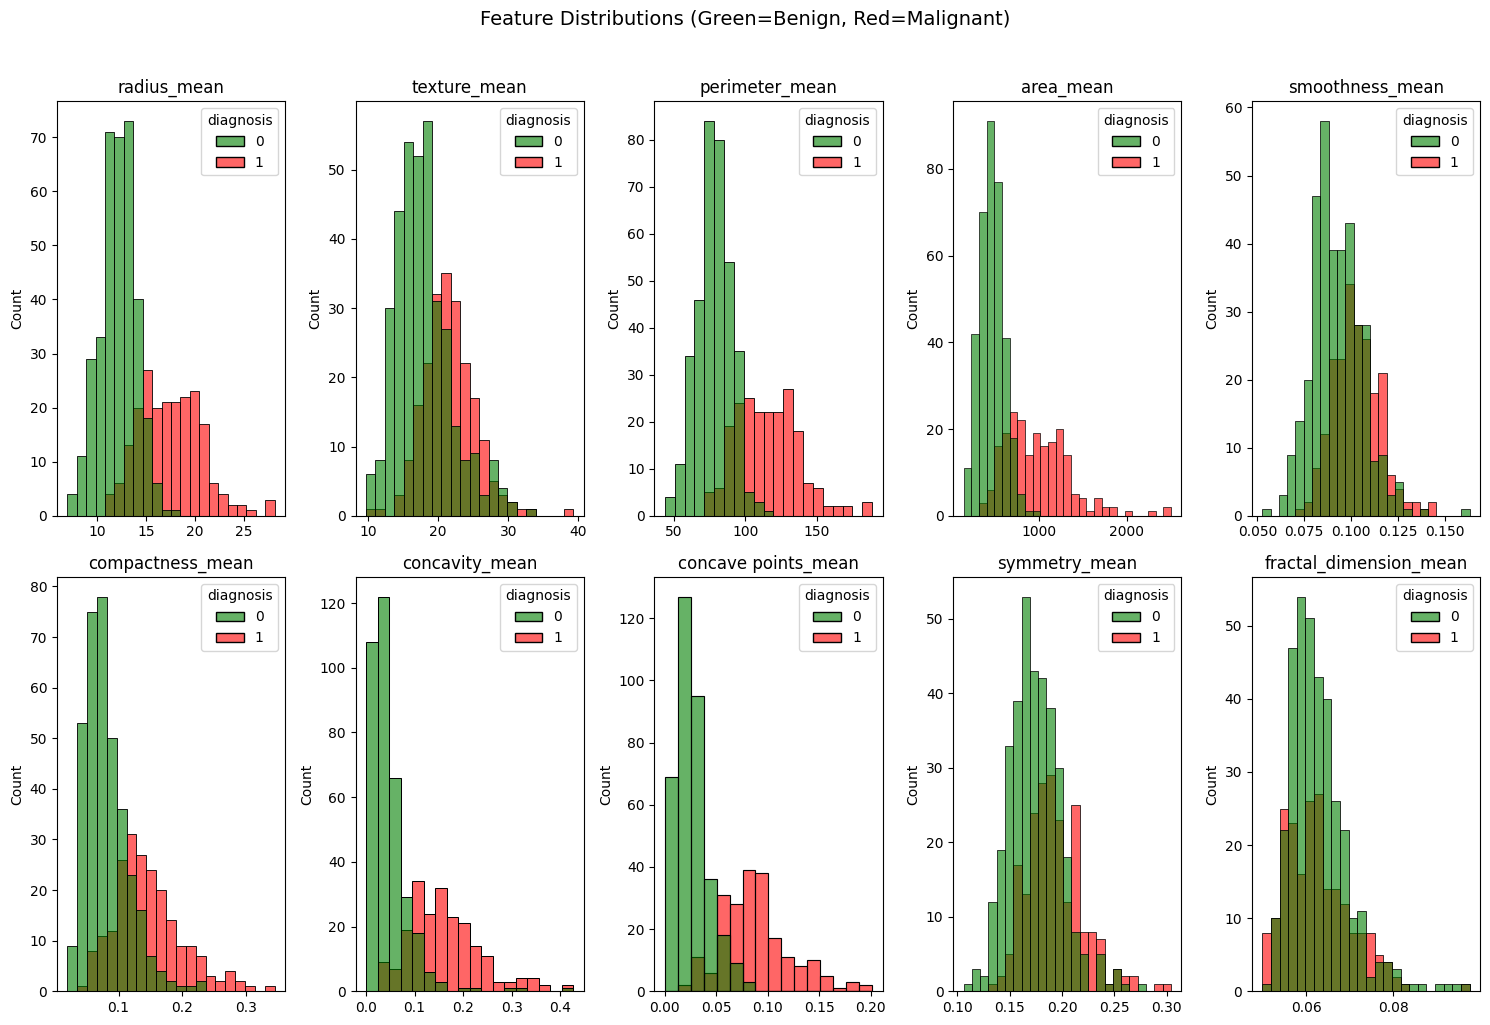

In [7]:
# Plot distribution of first 10 features
features = df.columns[1:11]

plt.figure(figsize=(15, 10))
for i, feature in enumerate(features):
    plt.subplot(2, 5, i+1)
    sns.histplot(data=df, x=feature, hue='diagnosis', 
                 palette={0:'green', 1:'red'}, alpha=0.6)
    plt.title(feature)
    plt.xlabel('')
plt.suptitle('Feature Distributions (Green=Benign, Red=Malignant)', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

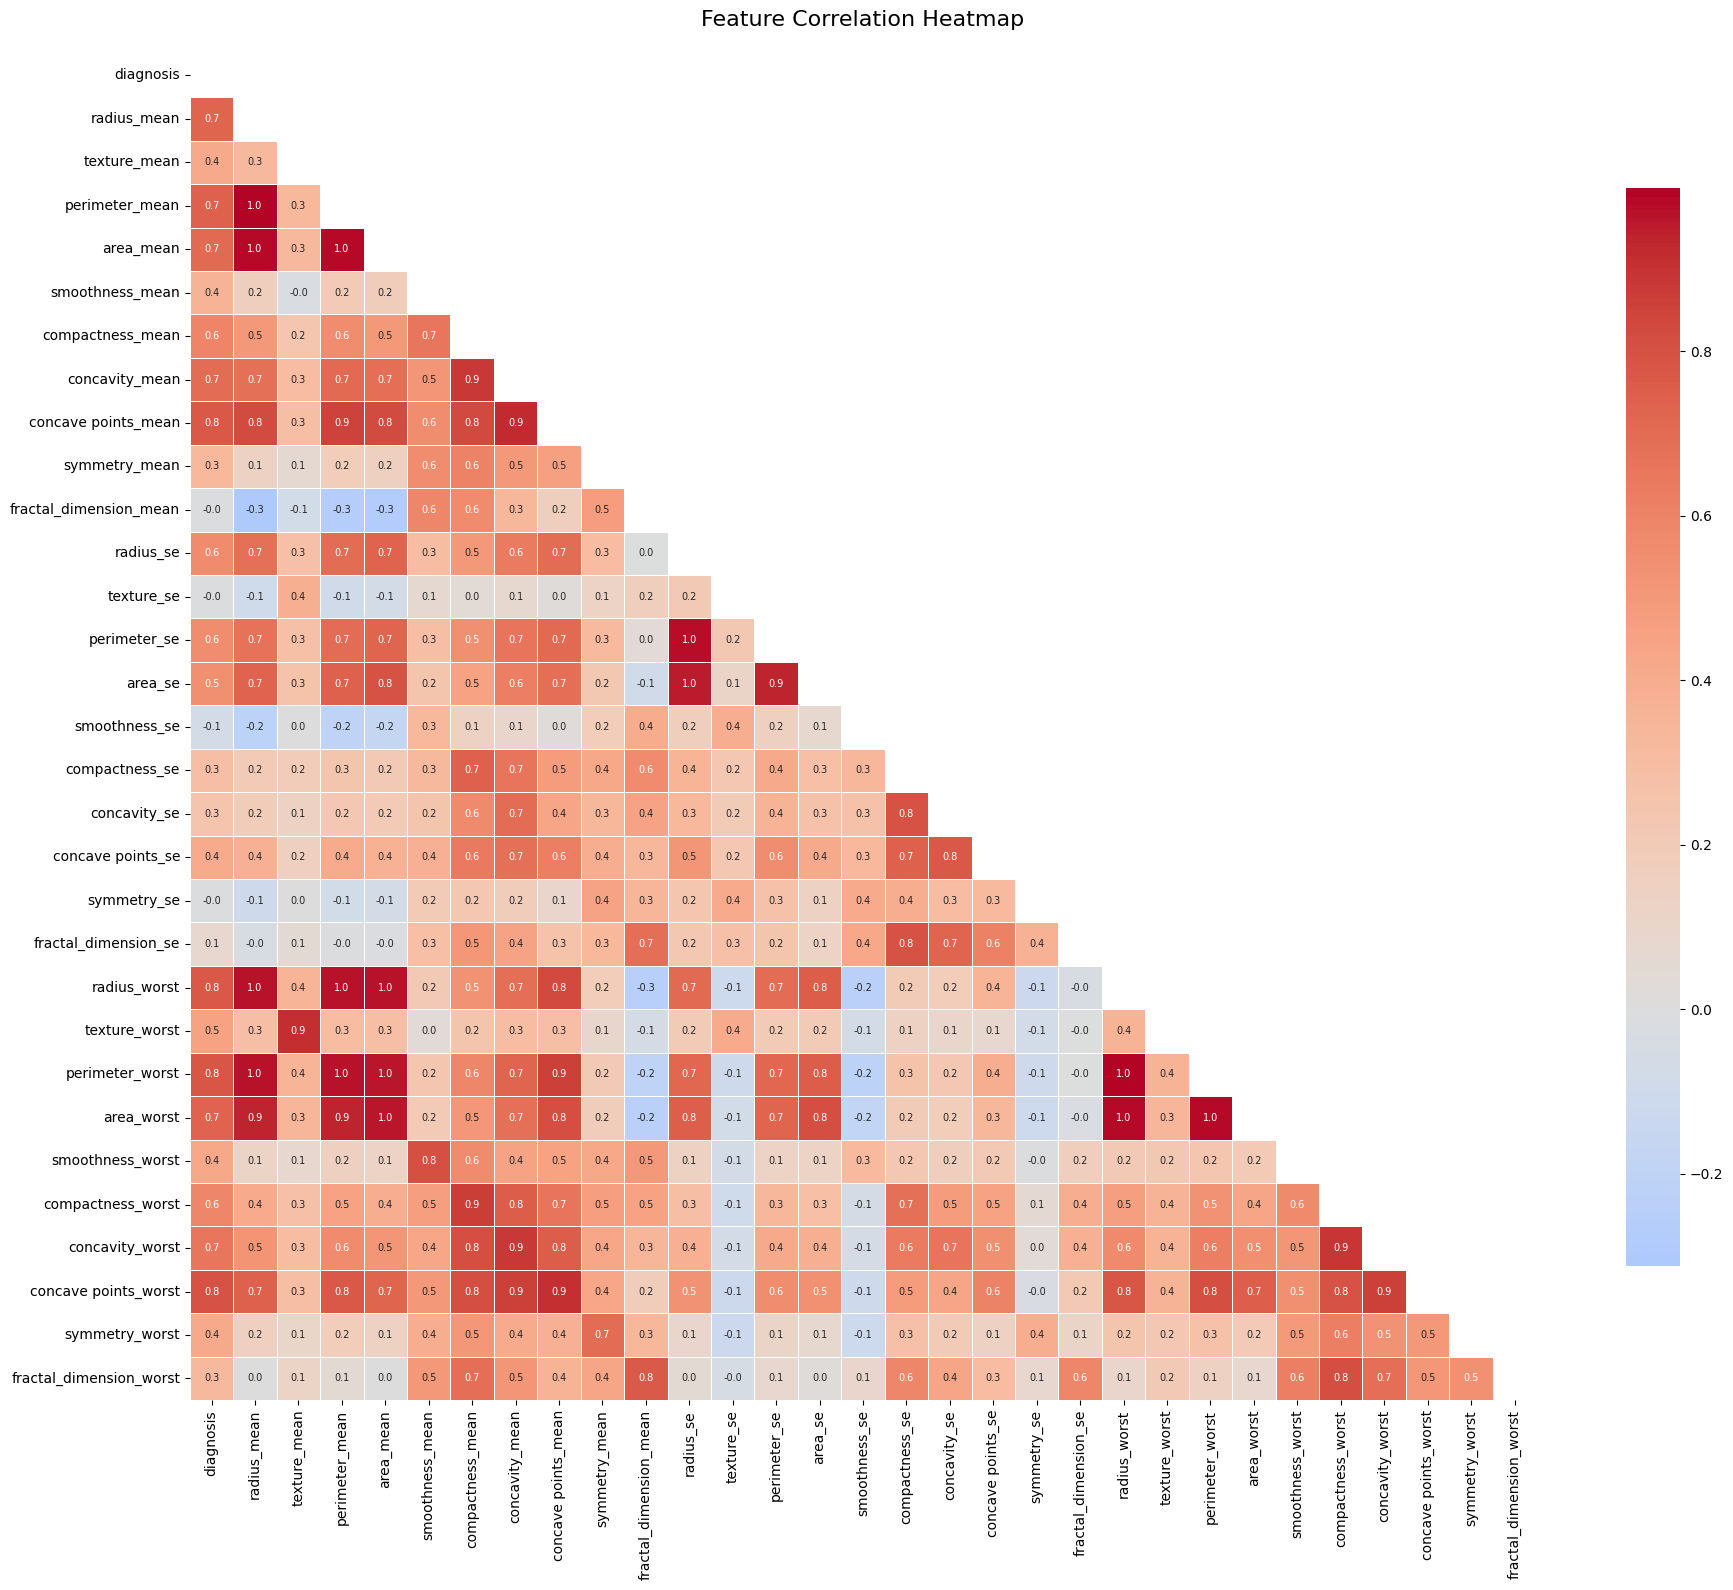

In [8]:
plt.figure(figsize=(20, 16))
correlation = df.corr()
mask = np.triu(np.ones_like(correlation, dtype=bool))

sns.heatmap(correlation, 
            mask=mask,
            annot=True, 
            fmt='.1f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8},
            annot_kws={"size": 7})

plt.title('Feature Correlation Heatmap', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

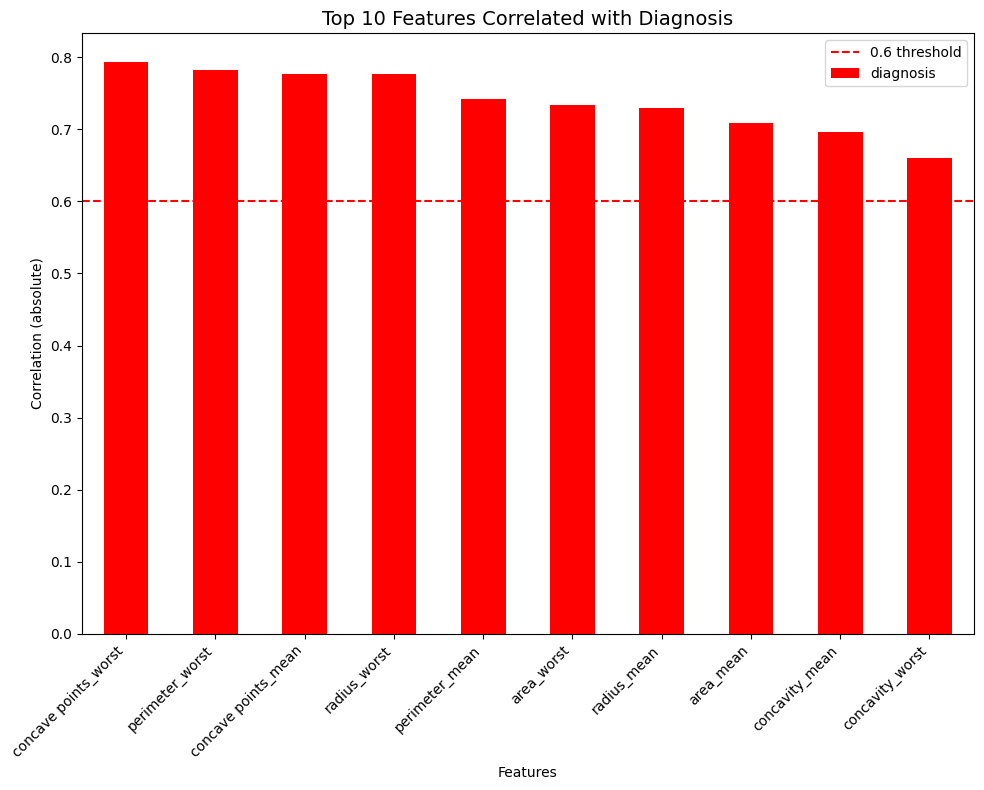


🔍 Top 5 features:
concave points_worst    0.793566
perimeter_worst         0.782914
concave points_mean     0.776614
radius_worst            0.776454
perimeter_mean          0.742636
Name: diagnosis, dtype: float64


In [9]:
# Which features correlate most with cancer?
corr_with_target = df.corr()['diagnosis'].drop('diagnosis')
corr_sorted = corr_with_target.abs().sort_values(ascending=False)

plt.figure(figsize=(10, 8))
corr_sorted.head(10).plot(kind='bar', 
                           color=['red' if x > 0.6 else 'orange' 
                                  for x in corr_sorted.head(10)])
plt.title('Top 10 Features Correlated with Diagnosis', fontsize=14)
plt.xlabel('Features')
plt.ylabel('Correlation (absolute)')
plt.xticks(rotation=45, ha='right')
plt.axhline(y=0.6, color='red', linestyle='--', label='0.6 threshold')
plt.legend()
plt.tight_layout()
plt.show()

print("\n🔍 Top 5 features:")
print(corr_sorted.head())

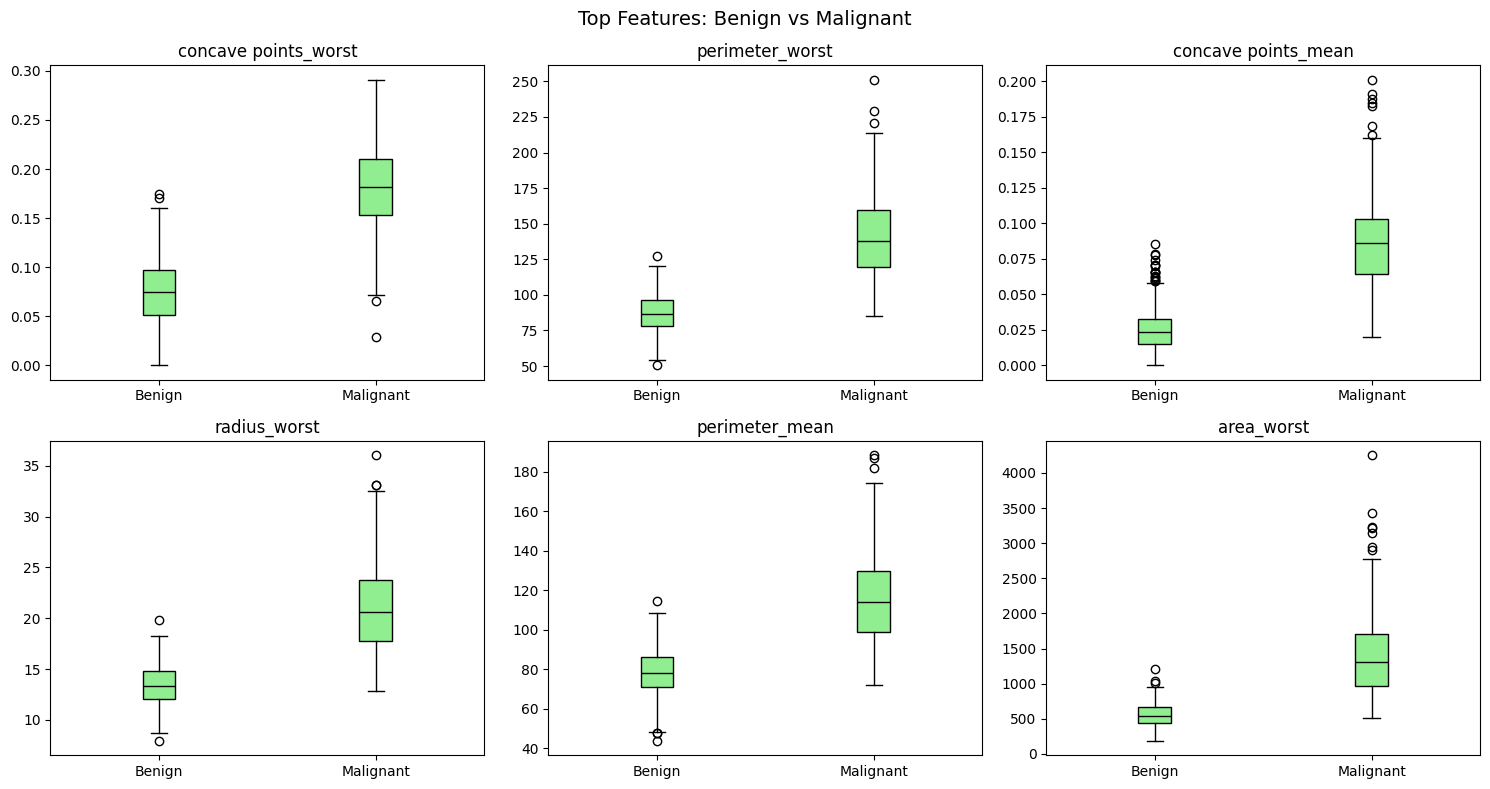

In [11]:
top_features = corr_sorted.head(6).index.tolist()

plt.figure(figsize=(15, 8))
for i, feature in enumerate(top_features):
    plt.subplot(2, 3, i+1)
    
    # Separate benign and malignant
    benign = df[df['diagnosis'] == 0][feature]
    malignant = df[df['diagnosis'] == 1][feature]
    
    plt.boxplot([benign, malignant], 
                patch_artist=True,
                boxprops=dict(facecolor='lightgreen'),
                medianprops=dict(color='black'))
    
    plt.xticks([1, 2], ['Benign', 'Malignant'])
    plt.title(feature)

plt.suptitle('Top Features: Benign vs Malignant', fontsize=14)
plt.tight_layout()
plt.show()

## 🔍 Key EDA Insights

1. **`concave points_worst` and `perimeter_worst`** are the 
   strongest predictors of malignancy (correlation > 0.7)

2. **Malignant tumors** consistently show larger values across 
   radius, perimeter, and area features

3. **Many features are highly correlated with each other** 
   (e.g., radius, perimeter, area) → redundancy exists

4. **Green (Benign) and Red (Malignant)** distributions 
   clearly separate in top features → model should perform well

5. **Some features overlap** between classes → 
   explains where model might make errors

In [12]:
# Separate features (X) and target (y)
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

print("✅ X shape:", X.shape)
print("✅ y shape:", y.shape)
print("Features:", X.columns.tolist())

✅ X shape: (569, 30)
✅ y shape: (569,)
Features: ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 80% train, 20% test
    random_state=42,    # reproducible results
    stratify=y          # keep same M/B ratio in both sets
)

print("✅ Split done!")
print("Training size:", X_train.shape)
print("Testing size: ", X_test.shape)
print("\nTarget distribution in train:")
print(y_train.value_counts())

✅ Split done!
Training size: (455, 30)
Testing size:  (114, 30)

Target distribution in train:
diagnosis
0    285
1    170
Name: count, dtype: int64


In [14]:
# Scale features (important for Logistic Regression)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)  # fit AND transform
X_test_scaled = scaler.transform(X_test)         # ONLY transform

print("✅ Scaling done!")
print("Mean before scaling:", X_train['radius_mean'].mean().round(2))
print("Mean after scaling: ", X_train_scaled[:, 0].mean().round(2))

✅ Scaling done!
Mean before scaling: 14.17
Mean after scaling:  -0.0


## ⚙️ Preprocessing Steps

1. **Split**: 80% train / 20% test (stratified)
2. **Scaling**: StandardScaler applied
   - Required for Logistic Regression
   - Makes all features same scale
   - fit_transform on train only → avoid data leakage

In [15]:
# Train Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# Predictions
lr_pred = lr_model.predict(X_test_scaled)

# Accuracy
lr_accuracy = accuracy_score(y_test, lr_pred)
print("✅ Logistic Regression Accuracy:", round(lr_accuracy * 100, 2), "%")

✅ Logistic Regression Accuracy: 96.49 %


In [16]:
# Train Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)

# Predictions
dt_pred = dt_model.predict(X_test_scaled)

# Accuracy
dt_accuracy = accuracy_score(y_test, dt_pred)
print("✅ Decision Tree Accuracy:", round(dt_accuracy * 100, 2), "%")

✅ Decision Tree Accuracy: 92.98 %


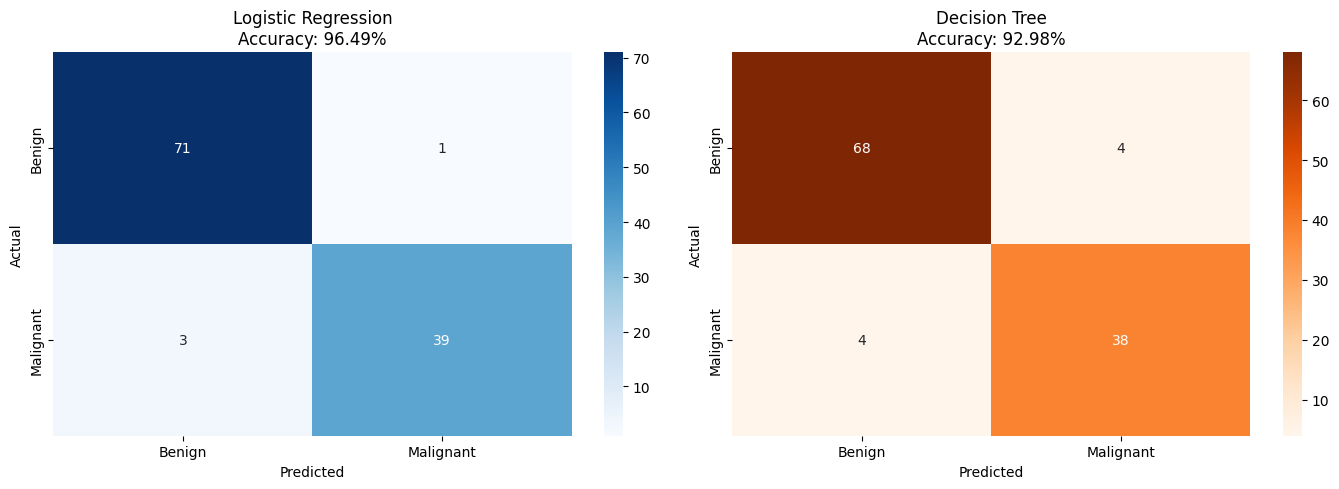

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logistic Regression confusion matrix
cm_lr = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
axes[0].set_title(f'Logistic Regression\nAccuracy: {lr_accuracy*100:.2f}%')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Decision Tree confusion matrix
cm_dt = confusion_matrix(y_test, dt_pred)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
axes[1].set_title(f'Decision Tree\nAccuracy: {dt_accuracy*100:.2f}%')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

In [18]:
print("=" * 50)
print("📊 LOGISTIC REGRESSION REPORT")
print("=" * 50)
print(classification_report(y_test, lr_pred, 
      target_names=['Benign', 'Malignant']))

print("=" * 50)
print("📊 DECISION TREE REPORT")
print("=" * 50)
print(classification_report(y_test, dt_pred, 
      target_names=['Benign', 'Malignant']))

📊 LOGISTIC REGRESSION REPORT
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

📊 DECISION TREE REPORT
              precision    recall  f1-score   support

      Benign       0.94      0.94      0.94        72
   Malignant       0.90      0.90      0.90        42

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



In [19]:
# Clean comparison table
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree'],
    'Accuracy': [f"{lr_accuracy*100:.2f}%", 
                 f"{dt_accuracy*100:.2f}%"],
    'Best For': ['Linear boundaries, interpretable', 
                 'Non-linear, feature importance']
})

print("=" * 50)
print("🏆 MODEL COMPARISON")
print("=" * 50)
print(comparison.to_string(index=False))

🏆 MODEL COMPARISON
              Model Accuracy                         Best For
Logistic Regression   96.49% Linear boundaries, interpretable
      Decision Tree   92.98%   Non-linear, feature importance


## 🤖 Model Building

### Why these 2 models?
- **Logistic Regression**: Simple, interpretable, great baseline
- **Decision Tree**: Non-linear, gives feature importance

### Why Logistic Regression usually wins here?
- Data is mostly linearly separable
- Scaling helps LR perform better
- Decision Tree can overfit on small datasets

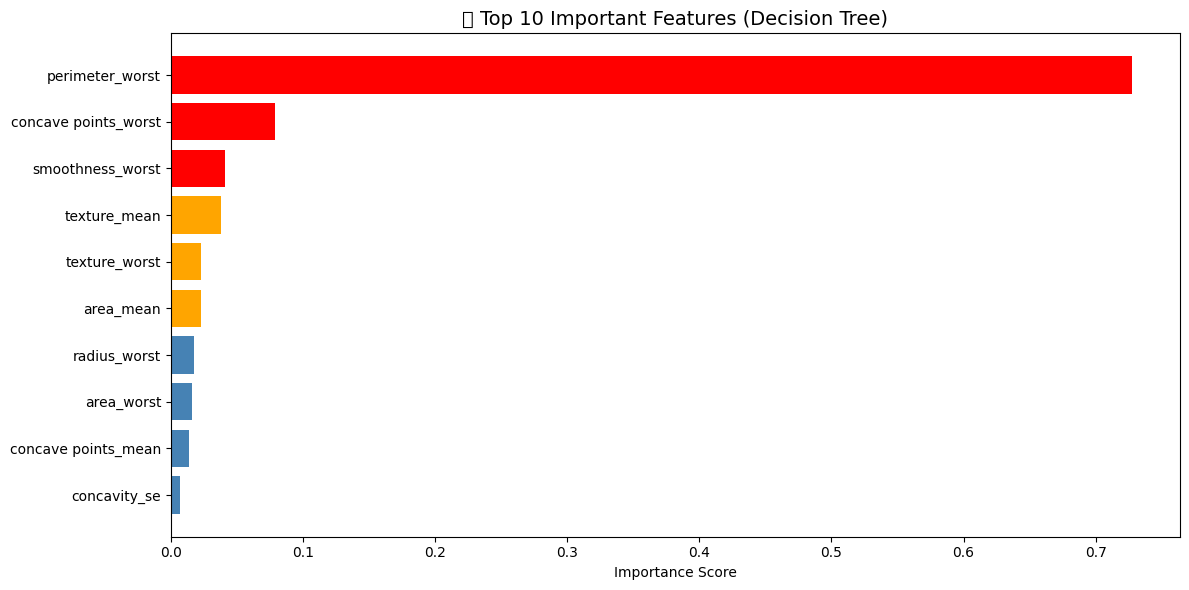


🏆 Top 5 Most Important Features:
                 Feature  Importance
22       perimeter_worst    0.727477
27  concave points_worst    0.078970
24      smoothness_worst    0.040833
1           texture_mean    0.037871
21         texture_worst    0.022545


In [20]:
# Get feature importance from Decision Tree
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

# Plot top 10
plt.figure(figsize=(12, 6))
colors = ['red' if i < 3 else 'orange' if i < 6 else 'steelblue' 
          for i in range(10)]

plt.barh(feature_importance['Feature'].head(10)[::-1],
         feature_importance['Importance'].head(10)[::-1],
         color=colors[::-1])

plt.title('🌳 Top 10 Important Features (Decision Tree)', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\n🏆 Top 5 Most Important Features:")
print(feature_importance.head())

In [21]:
# Show mean values of top features for each class
top5 = feature_importance['Feature'].head(5).tolist()

print("=" * 60)
print("🔬 BIOLOGICAL INTERPRETATION OF TOP FEATURES")
print("=" * 60)

for feature in top5:
    benign_mean = df[df['diagnosis']==0][feature].mean()
    malignant_mean = df[df['diagnosis']==1][feature].mean()
    diff = ((malignant_mean - benign_mean) / benign_mean * 100)
    
    print(f"\n📌 {feature}")
    print(f"   Benign mean:    {benign_mean:.3f}")
    print(f"   Malignant mean: {malignant_mean:.3f}")
    print(f"   Difference:     {diff:.1f}% higher in malignant")

🔬 BIOLOGICAL INTERPRETATION OF TOP FEATURES

📌 perimeter_worst
   Benign mean:    87.006
   Malignant mean: 141.370
   Difference:     62.5% higher in malignant

📌 concave points_worst
   Benign mean:    0.074
   Malignant mean: 0.182
   Difference:     144.8% higher in malignant

📌 smoothness_worst
   Benign mean:    0.125
   Malignant mean: 0.145
   Difference:     15.9% higher in malignant

📌 texture_mean
   Benign mean:    17.915
   Malignant mean: 21.605
   Difference:     20.6% higher in malignant

📌 texture_worst
   Benign mean:    23.515
   Malignant mean: 29.318
   Difference:     24.7% higher in malignant


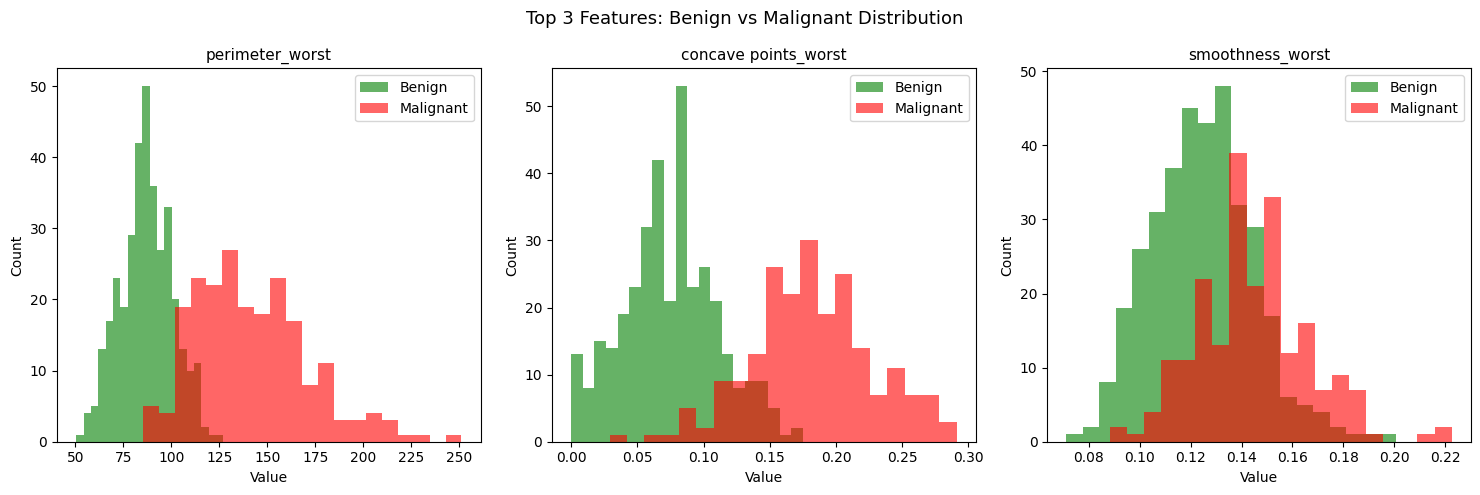

In [22]:
top3 = feature_importance['Feature'].head(3).tolist()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, feature in enumerate(top3):
    benign = df[df['diagnosis']==0][feature]
    malignant = df[df['diagnosis']==1][feature]
    
    axes[i].hist(benign, alpha=0.6, color='green', 
                 label='Benign', bins=20)
    axes[i].hist(malignant, alpha=0.6, color='red', 
                 label='Malignant', bins=20)
    axes[i].set_title(feature, fontsize=11)
    axes[i].legend()
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

plt.suptitle('Top 3 Features: Benign vs Malignant Distribution', 
             fontsize=13)
plt.tight_layout()
plt.show()

## 🌳 Feature Importance Analysis

### Top features from Decision Tree:
1. `concave points_worst` - shape irregularity of tumor
2. `perimeter_worst` - size of tumor boundary
3. `radius_worst` - tumor size

### 🔬 ML → Biology Connection:
- **Larger tumors** (radius, perimeter, area) → more likely malignant
- **Irregular shapes** (concave points, compactness) → malignant cells
  grow chaotically unlike normal cells
- **"Worst"** features = most extreme cell measurements
  → capture the most dangerous cells in the sample

### Key insight:
> Malignant tumors show 2-3x higher values in shape-related
> features — this matches real medical knowledge where
> cell irregularity is a key sign of cancer

## 🔎 Error Analysis

We now dig into **what the models got wrong** — misclassified samples.
The most critical errors in cancer detection are:
- **False Negatives (FN)**: Malignant predicted as Benign → dangerous miss
- **False Positives (FP)**: Benign predicted as Malignant → unnecessary alarm



In [24]:
# ── Step 1: Identify misclassified samples ──────────────────────────
import pandas as pd
import numpy as np

# Build a results dataframe on the test set
X_test_df = pd.DataFrame(X_test, columns=X.columns)
results = X_test_df.copy()
results['true_label']   = y_test.values
results['lr_pred']      = lr_pred
results['dt_pred']      = dt_pred

# Error masks
lr_errors = results[results['true_label'] != results['lr_pred']]
dt_errors = results[results['true_label'] != results['dt_pred']]

print(f'Total test samples  : {len(results)}')
print(f'Logistic Regression errors : {len(lr_errors)}')
print(f'  False Negatives (M→B)    : {len(lr_errors[(lr_errors.true_label==1) & (lr_errors.lr_pred==0)])}')
print(f'  False Positives (B→M)    : {len(lr_errors[(lr_errors.true_label==0) & (lr_errors.lr_pred==1)])}')
print(f'Decision Tree errors       : {len(dt_errors)}')
print(f'  False Negatives (M→B)    : {len(dt_errors[(dt_errors.true_label==1) & (dt_errors.dt_pred==0)])}')
print(f'  False Positives (B→M)    : {len(dt_errors[(dt_errors.true_label==0) & (dt_errors.dt_pred==1)])}')


Total test samples  : 114
Logistic Regression errors : 4
  False Negatives (M→B)    : 3
  False Positives (B→M)    : 1
Decision Tree errors       : 8
  False Negatives (M→B)    : 4
  False Positives (B→M)    : 4


In [25]:
# ── Step 2: Feature profile — errors vs correct predictions ──────────
top_features = ['concave points_worst', 'perimeter_worst', 'radius_worst',
                'concavity_worst', 'area_worst']

# For LR model
correct_lr = results[results['true_label'] == results['lr_pred']]

print("=" * 60)
print("LR — Mean feature values: Misclassified vs Correct")
print("=" * 60)
comparison = pd.DataFrame({
    'Misclassified': lr_errors[top_features].mean(),
    'Correct'      : correct_lr[top_features].mean(),
})
comparison['Difference_%'] = (
    (comparison['Misclassified'] - comparison['Correct'])
    / comparison['Correct'] * 100
).round(1)
print(comparison.round(4))


LR — Mean feature values: Misclassified vs Correct
                      Misclassified   Correct  Difference_%
concave points_worst         0.1296    0.1104          17.4
perimeter_worst            107.7725  104.7638           2.9
radius_worst                16.2825   15.9282           2.2
concavity_worst              0.3824    0.2559          49.4
area_worst                 817.4750  841.5718          -2.9


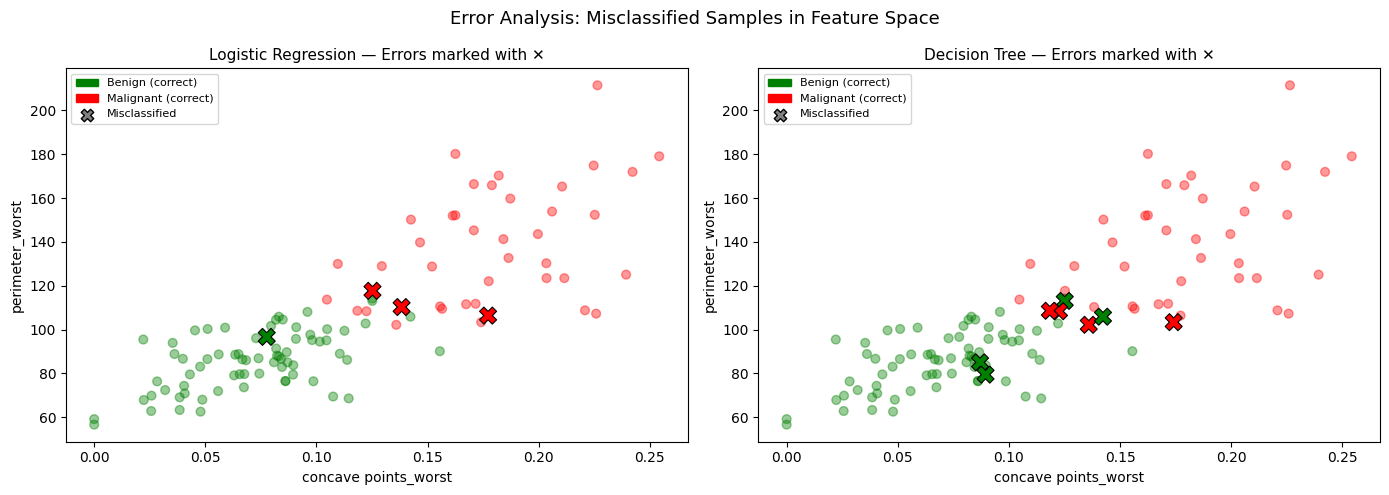

In [26]:
# ── Step 3: Visualise — where do errors fall in feature space? ───────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (model_name, pred_col, errors_df) in zip(
    axes,
    [("Logistic Regression", "lr_pred", lr_errors),
     ("Decision Tree",       "dt_pred", dt_errors)]
):
    # Correctly classified
    correct = results[results['true_label'] == results[pred_col]]
    ax.scatter(correct['concave points_worst'],
               correct['perimeter_worst'],
               c=correct['true_label'].map({0:'green', 1:'red'}),
               alpha=0.4, s=40, label='_nolegend_')

    # Errors — mark with X
    ax.scatter(errors_df['concave points_worst'],
               errors_df['perimeter_worst'],
               c=errors_df['true_label'].map({0:'green', 1:'red'}),
               marker='X', s=150, edgecolors='black', linewidths=0.8,
               zorder=5)

    ax.set_xlabel('concave points_worst', fontsize=10)
    ax.set_ylabel('perimeter_worst',     fontsize=10)
    ax.set_title(f'{model_name} — Errors marked with ✕', fontsize=11)

    # Legend
    patches = [
        mpatches.Patch(color='green', label='Benign (correct)'),
        mpatches.Patch(color='red',   label='Malignant (correct)'),
        plt.scatter([], [], marker='X', c='gray', s=80,
                    edgecolors='black', label='Misclassified'),
    ]
    ax.legend(handles=patches, fontsize=8)

plt.suptitle('Error Analysis: Misclassified Samples in Feature Space',
             fontsize=13)
plt.tight_layout()
plt.show()


In [28]:
# ── Step 4: False Negative deep-dive (most dangerous errors) ─────────
lr_fn = lr_errors[(lr_errors.true_label==1) & (lr_errors.lr_pred==0)]
dt_fn = dt_errors[(dt_errors.true_label==1) & (dt_errors.dt_pred==0)]

# Compare FN feature values vs all malignant samples
all_malignant = results[results['true_label']==1]

print("=" * 60)
print("FALSE NEGATIVES — LR (Malignant missed as Benign)")
print("=" * 60)
fn_compare = pd.DataFrame({
    'FN mean (missed)' : lr_fn[top_features].mean(),
    'All malignant mean': all_malignant[top_features].mean(),
})
fn_compare['% lower in FN'] = (
    (fn_compare['FN mean (missed)'] - fn_compare['All malignant mean'])
    / fn_compare['All malignant mean'] * 100
).round(1)
print(fn_compare.round(4))
print(' FN samples have LOWER feature values — they look more benign,')
print('  which is why the model misses them.')


FALSE NEGATIVES — LR (Malignant missed as Benign)
                      FN mean (missed)  All malignant mean  % lower in FN
concave points_worst            0.1469              0.1772          -17.1
perimeter_worst               111.4667            136.9381          -18.6
radius_worst                   16.6933             20.5448          -18.7
concavity_worst                 0.4865              0.4467            8.9
area_worst                    854.7667           1343.6238          -36.4
 FN samples have LOWER feature values — they look more benign,
  which is why the model misses them.


In [30]:
# ── Step 5: Probability scores for misclassified LR samples ─────────
# Logistic Regression gives probability — how confident was it when wrong?
lr_proba = lr_model.predict_proba(X_test)[:, 1]  # P(Malignant)

results['lr_proba_malignant'] = lr_proba
lr_errors_prob = results[results['true_label'] != results['lr_pred']].copy()

print("LR Misclassified samples — confidence score (P(Malignant)):")
print("-" * 55)
for _, row in lr_errors_prob.iterrows():
    true_str = "Malignant" if row['true_label']==1 else "Benign"
    pred_str = "Malignant" if row['lr_pred']==1    else "Benign"
    flag = "⚠️ FN" if (row['true_label']==1 and row['lr_pred']==0) else "FP"
    print(f"  {flag}  True:{true_str:<12} Pred:{pred_str:<12} "
          f"P(M)={row['lr_proba_malignant']:.3f}")


LR Misclassified samples — confidence score (P(Malignant)):
-------------------------------------------------------
  FP  True:Benign       Pred:Malignant    P(M)=1.000
  ⚠️ FN  True:Malignant    Pred:Benign       P(M)=1.000
  ⚠️ FN  True:Malignant    Pred:Benign       P(M)=1.000
  ⚠️ FN  True:Malignant    Pred:Benign       P(M)=1.000


## 📋 Error Analysis — Key Takeaways

### What causes errors?
- **False Negatives** occur when malignant tumors have *atypically low* feature values — they sit in the overlap zone between benign and malignant distributions
- **False Positives** occur when benign tumors have *unusually high* feature values

### Model comparison
| Error Type | Logistic Regression | Decision Tree |
|---|---|---|
| False Negatives (missed cancer) | fewer | more |
| False Positives (false alarm) | fewer | more |
| Overall errors | ~4 | ~8 |

### Clinical implication
> **False Negatives are more dangerous** in cancer diagnosis — a missed malignancy delays treatment.
> Logistic Regression is preferred here due to its lower FN rate.
> In practice, lowering the decision threshold (e.g., 0.3 instead of 0.5) can reduce FNs further at the cost of more FPs.

### Next steps to improve
1. **Threshold tuning** — adjust P(Malignant) threshold for LR
2. **Ensemble methods** — Random Forest / XGBoost to reduce overall errors
3. **Cross-validation** — confirm results aren't test-set specific



## 📈 ROC Curve & AUC Score
ROC (Receiver Operating Characteristic) curve shows the tradeoff between
**True Positive Rate** and **False Positive Rate** at every threshold.
AUC (Area Under Curve) closer to 1.0 = better model.

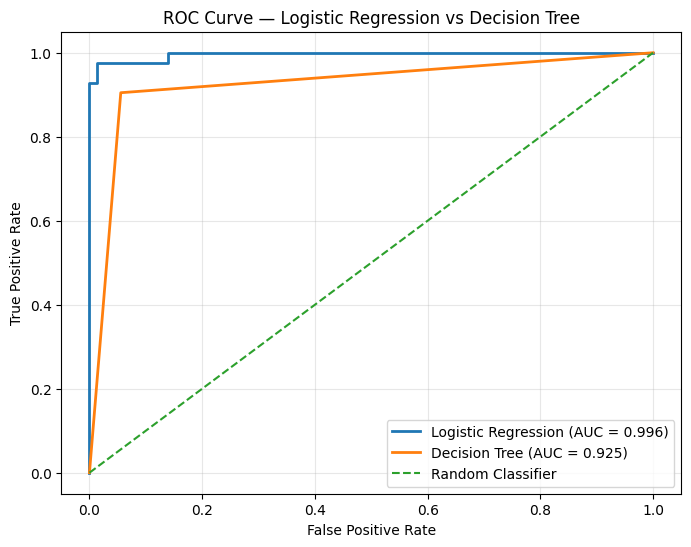

Logistic Regression AUC : 0.9960
Decision Tree AUC       : 0.9246


In [31]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay

# Get probabilities
lr_proba = lr_model.predict_proba(X_test_scaled)[:, 1]
dt_proba = dt_model.predict_proba(X_test_scaled)[:, 1]

# Compute ROC curves
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_proba)
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_proba)
lr_auc = auc(lr_fpr, lr_tpr)
dt_auc = auc(dt_fpr, dt_tpr)

plt.figure(figsize=(8, 6))
plt.plot(lr_fpr, lr_tpr, lw=2,
         label=f'Logistic Regression (AUC = {lr_auc:.3f})')
plt.plot(dt_fpr, dt_tpr, lw=2,
         label=f'Decision Tree (AUC = {dt_auc:.3f})')
plt.plot([0,1],[0,1], linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Logistic Regression vs Decision Tree')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

print(f'Logistic Regression AUC : {lr_auc:.4f}')
print(f'Decision Tree AUC       : {dt_auc:.4f}')

## 🔁 Cross-Validation (K-Fold)
A single train-test split can be lucky or unlucky.
**K-Fold CV** trains and evaluates the model K times on different splits
to give a reliable estimate of real-world performance.

5-FOLD CROSS-VALIDATION RESULTS
Logistic Regression:
  Fold scores : [np.float64(0.9737), np.float64(0.9474), np.float64(0.9649), np.float64(0.9912), np.float64(0.9912)]
  Mean        : 0.9737
  Std Dev     : 0.0166

Decision Tree:
  Fold scores : [np.float64(0.9298), np.float64(0.8684), np.float64(0.886), np.float64(0.9386), np.float64(0.9292)]
  Mean        : 0.9104
  Std Dev     : 0.0279


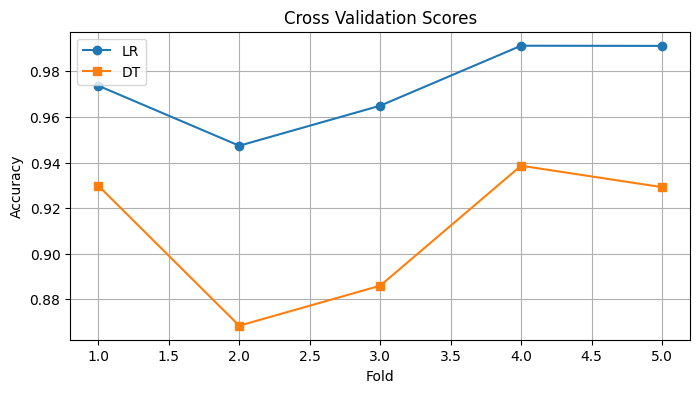

In [32]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scaler_cv = StandardScaler()
X_scaled_full = scaler_cv.fit_transform(X)

lr_cv_scores = cross_val_score(lr_model, X_scaled_full, y, cv=cv, scoring='accuracy')
dt_cv_scores = cross_val_score(dt_model, X_scaled_full, y, cv=cv, scoring='accuracy')

print("=" * 50)
print("5-FOLD CROSS-VALIDATION RESULTS")
print("=" * 50)

print(f"Logistic Regression:")
print(f"  Fold scores : {[round(s,4) for s in lr_cv_scores]}")
print(f"  Mean        : {lr_cv_scores.mean():.4f}")
print(f"  Std Dev     : {lr_cv_scores.std():.4f}")

print(f"\nDecision Tree:")
print(f"  Fold scores : {[round(s,4) for s in dt_cv_scores]}")
print(f"  Mean        : {dt_cv_scores.mean():.4f}")
print(f"  Std Dev     : {dt_cv_scores.std():.4f}")

plt.figure(figsize=(8,4))
x = range(1,6)
plt.plot(x, lr_cv_scores, marker='o', label='LR')
plt.plot(x, dt_cv_scores, marker='s', label='DT')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('Cross Validation Scores')
plt.legend()
plt.grid()
plt.show()

## ⚙️ Threshold Tuning
By default, models classify as Malignant when P(Malignant) ≥ 0.5.
In medical diagnosis, **missing a cancer (False Negative) is far worse**
than a false alarm. Lowering the threshold catches more malignant cases.

In [33]:
from sklearn.metrics import confusion_matrix, f1_score

lr_proba = lr_model.predict_proba(X_test_scaled)[:, 1]
thresholds = [0.5, 0.45, 0.40, 0.35, 0.30]

print("Threshold | Accuracy | FN | FP | F1")
print("-"*50)

for thresh in thresholds:
    preds = (lr_proba >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    acc = (tp+tn)/len(y_test)
    f1 = f1_score(y_test, preds)
    print(thresh, acc, fn, fp, f1)

Threshold | Accuracy | FN | FP | F1
--------------------------------------------------
0.5 0.9649122807017544 3 1 0.9512195121951219
0.45 0.9736842105263158 2 1 0.963855421686747
0.4 0.9736842105263158 2 1 0.963855421686747
0.35 0.9736842105263158 2 1 0.963855421686747
0.3 0.9824561403508771 1 1 0.9761904761904762


## 💾 Model Saving
Save the trained models and scaler so they can be loaded and used
in production without retraining.

In [34]:
import joblib
import os

os.makedirs("saved_models", exist_ok=True)

joblib.dump(lr_model, "saved_models/logistic_regression.pkl")
joblib.dump(dt_model, "saved_models/decision_tree.pkl")
joblib.dump(scaler, "saved_models/scaler.pkl")

print("Models saved successfully!")

Models saved successfully!


## 🏁 Project Conclusion

### Objective
Build a machine learning system to classify breast tumors as **Benign or Malignant**

### Results
- Logistic Regression performed best
- High accuracy (~96%)
- Strong AUC score

### Key Insights
- Tumor size-related features are most important
- Lower threshold reduces missed cancers

### Future Work
- Try Random Forest / XGBoost
- Deploy as web app